In [3]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [1]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


In [2]:
#Q1

# Call Time.now() exactly once
now = Time.now()

# Print UTC
print("Current UTC:", now.utc.isot)

# Print IIT Kanpur civil time
print("IIT Kanpur time:", format_iitk(now))

Current UTC: 2026-09-05T15:43:37.250
IIT Kanpur time: 2026-09-05 21:13:37 IST


In [3]:
#Q2
# Create the quantities
height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

# Convert them
height_km = height.to(u.km)
frequency_THz = wavelength.to(u.THz, equivalencies=u.spectral())
uncertainty_arcsec = uncertainty.to(u.arcsec)
cadence_hours = cadence.to(u.hour)
wavelength_cm = frequency.to(u.cm, equivalencies=u.spectral())

# Print original and converted values
print("GTC height:", height, "=", height_km)
print("Wavelength:", wavelength, "=", frequency_THz)
print("Coordinate uncertainty:", uncertainty, "=", uncertainty_arcsec)
print("Cadence:", cadence, "=", cadence_hours)
print("Radio frequency:", frequency, "=", wavelength_cm)

GTC height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Radio frequency: 1.4 GHz = 21.413747 cm


In [4]:
planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.isot)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IIT Kanpur:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour

print("Later UTC:", later.utc.isot)
print("Later IIT Kanpur:", format_iitk(later))

ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
round_trip = Time(ist_datetime)

difference = abs((round_trip - planning_start).to_value(u.s))

print("Round-trip difference:", difference, "seconds")
print("Less than one microsecond:", difference < 1e-6)

UTC: 2026-08-30T12:00:00.000
JD: 2461283.0
MJD: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30T14:15:00.000
Later IIT Kanpur: 2026-08-30 19:45:00 IST
Round-trip difference: 0.0 seconds
Less than one microsecond: True


In [5]:
ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(ra=ra, dec=dec, frame="icrs")

print("RA (deg):", frb_icrs.ra.deg)
print("Dec (deg):", frb_icrs.dec.deg)

print("RA (hms):", frb_icrs.ra.to_string(unit=u.hourangle, sep=":", pad=True))
print("Dec (dms):", frb_icrs.dec.to_string(unit=u.deg, sep=":", pad=True))

ra_expected = 347.2704120833
dec_expected = 48.7066410556

print("RA verified:", abs(frb_icrs.ra.deg - ra_expected) < 1e-8)
print("Dec verified:", abs(frb_icrs.dec.deg - dec_expected) < 1e-8)

RA (deg): 347.27041208333327
Dec (deg): 48.70664105555556
RA (hms): 23:09:04.8989
Dec (dms): 48:42:23.9078
RA verified: True
Dec verified: True


RA is expressed in hours because it is related to Earth's rotation and the 24-hour celestial coordinate system. Declination is an angular distance from the celestial equator, so it is expressed in degrees.

In [6]:


# Transform ICRS → Galactic
frb_galactic = frb_icrs.galactic

print("Galactic longitude l:", frb_galactic.l.deg)
print("Galactic latitude b:", frb_galactic.b.deg)

# Transform Galactic → ICRS
frb_icrs_back = frb_galactic.icrs

# Calculate round-trip separation
separation = frb_icrs.separation(frb_icrs_back)

print("Round-trip separation (microarcseconds):",
      separation.to(u.microarcsecond))

Galactic longitude l: 106.06496077332801
Galactic latitude b: -10.784176285402493
Round-trip separation (microarcseconds): 0.000310733 uarcsec


The tiny non-zero round-trip separation is due to floating-point numerical precision and rounding during the coordinate transformations. It is not a real change in the FRB's position; mathematically, transforming ICRS → Galactic → ICRS should return the original coordinates.

In [7]:
from astropy.coordinates import BarycentricTrueEcliptic

# Transform ICRS → Barycentric True Ecliptic (J2000)
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox="J2000")
)

# Print ecliptic coordinates
print("Ecliptic longitude λ (deg):", frb_ecliptic.lon.deg)
print("Ecliptic latitude β (deg):", frb_ecliptic.lat.deg)

# Verify valid ranges
print("λ valid:", 0 <= frb_ecliptic.lon.deg < 360)
print("β valid:", -90 <= frb_ecliptic.lat.deg <= 90)

# Transform back to ICRS
frb_icrs_back = frb_ecliptic.icrs

# Calculate round-trip separation
separation = frb_icrs.separation(frb_icrs_back)

print("Round-trip separation (microarcseconds):",
      separation.to(u.microarcsecond))

Ecliptic longitude λ (deg): 14.411187650340095
Ecliptic latitude β (deg): 48.34695843744783
λ valid: True
β valid: True
Round-trip separation (microarcseconds): 0 uarcsec


The ecliptic plane is basically the plane of Earth's orbit around the Sun.

Think of it as a huge flat reference plane projected onto the sky.

Ecliptic longitude $\lambda$ tells you where around the ecliptic the object appears.
Ecliptic latitude $\beta$ tells you how far above or below the ecliptic plane the object appears.

In [8]:
# Construct earlier position
earlier_position = SkyCoord(
    "23h09m04.9s",
    "+48d42m25.4s",
    frame="icrs"
)

# Convert to radians
ra1 = frb_icrs.ra.rad
dec1 = frb_icrs.dec.rad

ra2 = earlier_position.ra.rad
dec2 = earlier_position.dec.rad

# Great-circle formula
cos_delta_theta = (
    np.sin(dec1) * np.sin(dec2)
    + np.cos(dec1) * np.cos(dec2) * np.cos(ra2 - ra1)
)

# Clip to [-1, 1]
cos_delta_theta = np.clip(cos_delta_theta, -1.0, 1.0)

# Separation in radians
delta_theta = np.arccos(cos_delta_theta)

# Convert to arcsec
manual_arcsec = np.degrees(delta_theta) * 3600
manual_mas = manual_arcsec * 1000

# Astropy result
astropy_arcsec = frb_icrs.separation(earlier_position).to_value(u.arcsec)



# Difference
difference = abs(manual_arcsec - astropy_arcsec)

print("Manual separation:", manual_arcsec, "arcsec")
print("Manual separation:", manual_mas, "mas")

print("Astropy separation:", astropy_arcsec, "arcsec")
print("Difference:", difference, "arcsec")


Manual separation: 1.4922374490540065 arcsec
Manual separation: 1492.2374490540064 mas
Astropy separation: 1.492239726203449 arcsec
Difference: 2.277149442564408e-06 arcsec


In [9]:
from astropy.coordinates import EarthLocation
import astropy.units as u


# Define the GTC observing site

gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

# Recover and print the geodetic values
lon = gtc_location.lon.to(u.deg)
lat = gtc_location.lat.to(u.deg)
height = gtc_location.height.to(u.m)

print("GTC longitude:", lon)
print("GTC latitude:", lat)
print("GTC height:", height)

GTC longitude: -17d53m20.4s
GTC latitude: 28d45m28.8s
GTC height: 2395.9999999997463 m


The negative longitude means that the GTC is located 17.889° west of the Greenwich meridian

In [10]:
from astropy.time import Time
import astropy.units as u

# Observation time
t = Time("2026-08-31T00:00:00Z")

# Apparent Local Sidereal Time at GTC
lst = t.sidereal_time("apparent", longitude=gtc_location.lon)

# Target RA
ra = frb_icrs.ra

# Hour angle
ha = (lst - ra).wrap_at(12 * u.hourangle)

print("UTC:", t.isot)
print("LST:", lst.to_string(unit=u.hour))
print("Hour angle:", ha.to_string(unit=u.hour))

UTC: 2026-08-31T00:00:00.000
LST: 21h25m12.29517887s
Hour angle: -1h43m52.60372113s


Target is east of the meridian

In [11]:
# Calculate LST and hour angle for all 145 samples

lst_all = times.sidereal_time(
    "apparent",
    longitude=gtc_location.lon
)

ha_all = (lst_all - frb_icrs.ra).wrap_at(12 * u.hourangle)

# Find the sample with the smallest absolute hour angle
nearest_idx = np.argmin(np.abs(ha_all))

print("Sample index:", nearest_idx)
print("UTC:", times[nearest_idx].isot)
print("IIT Kanpur time:", times[nearest_idx].to_datetime())
print("LST:", lst_all[nearest_idx].to_string(unit=u.hour))
print("Hour angle:", ha_all[nearest_idx].to_string(unit=u.hour))

Sample index: 82
UTC: 2026-08-31T01:40:00.000
IIT Kanpur time: 2026-08-31 01:40:00
LST: 23h05m28.72210035s
Hour angle: -0h03m36.17679965s


The result is a sampled approximation because the hour angle is calculated only at the 145 given sample times. The actual meridian transit occurs when the hour angle is exactly zero, which may occur between two sampled times. Therefore, the sample with the smallest absolute hour angle is the nearest sampled transit, not necessarily the exact transit instant.

In [12]:

# GTC latitude and target declination
phi = gtc_location.lat
delta = frb_icrs.dec

# Analytic transit altitude
h_transit = 90 * u.deg - np.abs(phi - delta)

# Zenith distance
z_transit = 90 * u.deg - h_transit

print("Predicted transit altitude:", h_transit)
print("Predicted zenith distance:", z_transit)

# Transform target to AltAz for all grid times
altaz_frame = AltAz(
    obstime=times,
    location=gtc_location
)

frb_altaz = frb_icrs.transform_to(altaz_frame)

# Find largest sampled altitude
max_alt_idx = np.argmax(frb_altaz.alt)

max_alt = frb_altaz.alt[max_alt_idx]
max_z = frb_altaz.zen[max_alt_idx]

print("\nLargest sampled altitude:", max_alt)
print("Sample index:", max_alt_idx)
print("UTC:", times[max_alt_idx].isot)
print("Sampled zenith distance:", max_z)

print("\nAltitude difference:",
      (max_alt - h_transit).to(u.arcsec))
print("Zenith-distance difference:",
      (max_z - z_transit).to(u.arcsec))

Predicted transit altitude: 70d03m04.8922s
Predicted zenith distance: 19d56m55.1078s

Largest sampled altitude: 69d53m01.94324592s
Sample index: 82
UTC: 2026-08-31T01:40:00.000
Sampled zenith distance: 20d06m58.05675408s

Altitude difference: -602.949 arcsec
Zenith-distance difference: 602.949 arcsec


In [13]:
# Indices from Q10: nearest transit
transit_idx = nearest_idx

# Find the samples closest to 2 hours before and after transit
before_idx = transit_idx - 12 #samples are 10 min apart, 2 hours = 120 min /10min = 12
after_idx = transit_idx + 12

# Latitude and declination in radians
phi = gtc_location.lat.to(u.rad).value
delta = frb_icrs.dec.to(u.rad).value

for label, idx in [
    ("2 hours before transit", before_idx),
    ("At transit", transit_idx),
    ("2 hours after transit", after_idx)
]:

    # Hour angle in radians
    H = ha_all[idx].to(u.rad).value

    # Altitude equation
    sin_h = (
        np.sin(phi) * np.sin(delta)
        + np.cos(phi) * np.cos(delta) * np.cos(H)
    )

    sin_h = np.clip(sin_h, -1, 1)

    h = np.arcsin(sin_h) * u.rad

    print("\n", label)
    print("Sample index:", idx)
    print("UTC:", times[idx].isot)
    print("Hour angle:", ha_all[idx].to_string(unit=u.hour))
    print("Calculated altitude:", h.to(u.deg))
    print("Astropy altitude:", frb_altaz.alt[idx])


 2 hours before transit
Sample index: 70
UTC: 2026-08-30T23:40:00.000
Hour angle: -2h03m55.88910448s
Calculated altitude: 59.032158349271114 deg
Astropy altitude: 58d46m54.28676984s

 At transit
Sample index: 82
UTC: 2026-08-31T01:40:00.000
Hour angle: -0h03m36.17679965s
Calculated altitude: 70.03935712992158 deg
Astropy altitude: 69d53m01.94324592s

 2 hours after transit
Sample index: 94
UTC: 2026-08-31T03:40:00.000
Hour angle: 1h56m43.53551704s
Calculated altitude: 60.06283863737094 deg
Astropy altitude: 60d09m44.51549183s


In [14]:
import numpy as np
import astropy.units as u

# Minimum altitude
h_min = 20 * u.deg

# Latitude and declination in radians
phi = gtc_location.lat.to(u.rad).value
delta = frb_icrs.dec.to(u.rad).value
hmin = h_min.to(u.rad).value

# Calculate cos(H0)
cos_H0 = (
    np.sin(hmin) - np.sin(phi) * np.sin(delta)
) / (
    np.cos(phi) * np.cos(delta)
)

# Avoid numerical problems
cos_H0 = np.clip(cos_H0, -1, 1)

# Calculate H0
H0_rad = np.arccos(cos_H0)

# Convert to degrees and sidereal hours
H0_deg = np.degrees(H0_rad)
H0_hours = H0_deg / 15

# Total time above 20 degrees
total_hours = 2 * H0_hours

# Count actual grid samples above 20 degrees
above_20 = frb_altaz.alt >= h_min
n_samples = np.count_nonzero(above_20)

print("H0:", H0_deg, "degrees")
print("H0:", H0_hours, "sidereal hours")
print("Total time above 20 degrees:", total_hours, "hours")
print("Number of grid samples above 20 degrees:", n_samples)

H0: 91.92747700350239 degrees
H0: 6.128498466900159 sidereal hours
Total time above 20 degrees: 12.256996933800318 hours
Number of grid samples above 20 degrees: 74


In [15]:
import numpy as np
import astropy.units as u

# Transform FRB to AltAz at GTC
frb_gtc_altaz = frb_icrs.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

# Calculate target airmass
target_airmass = np.array(frb_gtc_altaz.secz, dtype=float)

# Replace invalid values with NaN
target_airmass[
    (frb_gtc_altaz.alt <= 0 * u.deg) |
    (~np.isfinite(target_airmass)) |
    (target_airmass < 1)
] = np.nan

# Finite airmass range
finite_airmass = target_airmass[np.isfinite(target_airmass)]

print("Finite airmass range:",
      np.min(finite_airmass), "to", np.max(finite_airmass))

# Best airmass
best_idx = np.nanargmin(target_airmass)

print("Best airmass:", target_airmass[best_idx])
print("UTC:", times[best_idx].isot)

from zoneinfo import ZoneInfo

print("IST:",
      times[best_idx].to_datetime(
          timezone=ZoneInfo("Asia/Kolkata")
      ).strftime("%Y-%m-%d %H:%M:%S IST"))

# Number of samples with 1 <= X <= 2.5
safe_samples = (
    (target_airmass >= 1) &
    (target_airmass <= 2.5)
)

print("Samples with 1 <= X <= 2.5:",
      np.count_nonzero(safe_samples))

Finite airmass range: 1.0649655775500655 to 55.34987513096205
Best airmass: 1.0649655775500655
UTC: 2026-08-31T01:40:00.000
IST: 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68


Airmass represents the relative path length through the Earth's atmosphere compared with observing the source at the zenith. It is approximately given by \(X=\sec z\), where \(z\) is the zenith distance. An airmass of 1 corresponds to the zenith, while larger values indicate that the source is observed through more atmosphere. Below-horizon values must not be used because the source is not physically observable and the mathematical value of secz is not a meaningful observing airmass.

In [16]:
from astropy.coordinates import get_sun, get_body, AltAz
import numpy as np
import astropy.units as u

# Sun and Moon positions
sun = get_sun(times)
moon = get_body("moon", times, location=gtc_location)

# Convert Sun and Moon to Alt/Az at GTC
sun_altaz = sun.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

moon_altaz = moon.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

# 1. Sun altitude
sun_altitude = sun_altaz.alt

# 2. Moon altitude
moon_altitude = moon_altaz.alt

# 3. Moon airmass
moon_airmass = moon_altaz.secz.value.astype(float)

# Keep Moon airmass only when Moon is above horizon and 1 <= X <= 3
moon_airmass[
    (moon_altitude <= 0 * u.deg) |
    (~np.isfinite(moon_airmass)) |
    (moon_airmass < 1) |
    (moon_airmass > 3)
] = np.nan

# 4. Moon-target separation
moon_target_sep = moon.separation(frb_icrs)

# 5. Sun-Moon elongation
sun_moon_elongation = sun.separation(moon)

# Illuminated fraction
epsilon = sun_moon_elongation.to(u.rad).value
illuminated_fraction = (1 - np.cos(epsilon)) / 2

print("Sun altitude range:", sun_altitude.min(), "to", sun_altitude.max())
print("Moon altitude range:", moon_altitude.min(), "to", moon_altitude.max())
print("Moon airmass range:",
      np.nanmin(moon_airmass), "to", np.nanmax(moon_airmass))
print("Moon-target separation range:",
      moon_target_sep.min(), "to", moon_target_sep.max())
print("Illuminated fraction range:",
      illuminated_fraction.min(), "to", illuminated_fraction.max())

Sun altitude range: -52d32m57.36817221s to 70d06m18.5700086s
Moon altitude range: -56d08m31.1641664s to 69d42m31.12088371s
Moon airmass range: 1.0661648368108945 to 2.8951432130069588
Moon-target separation range: 44d33m56.44313934s to 46d22m56.06701774s
Illuminated fraction range: 0.8791968994517614 to 0.9406682728544431


 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

In [17]:
def visibility(altitude, airmass, sun_altitude, moon_separation):

    condition_altitude = altitude >= 20 * u.deg

    condition_airmass = (
        np.isfinite(airmass) &
        (airmass >= 1) &
        (airmass <= 2.5)
    )

    condition_sun = sun_altitude <= -18 * u.deg

    condition_moon = moon_separation >= 30 * u.deg

    result = (
        condition_altitude &
        condition_airmass &
        condition_sun &
        condition_moon
    )

    return result

visible = visibility(
    frb_gtc_altaz.alt,
    target_airmass,
    sun_altitude,
    moon_target_sep
)

print("Number of visible samples:", np.count_nonzero(visible))
print("Any visible sample:", np.any(visible))

Number of visible samples: 51
Any visible sample: True


In [18]:
from astropy.time import Time
from astropy.coordinates import AltAz, get_sun, get_body
import astropy.units as u
import numpy as np
from zoneinfo import ZoneInfo

# Two times to test
check_times = Time([
    times[nearest_idx].isot,          # nearest sampled transit from Q10
    "2026-08-31T06:00:00Z"
])

# Target altitude and airmass
target_altaz = frb_icrs.transform_to(
    AltAz(obstime=check_times, location=gtc_location)
)

target_altitude = target_altaz.alt
target_airmass = np.array(target_altaz.secz, dtype=float)

# Sun
sun = get_sun(check_times)
sun_altaz = sun.transform_to(
    AltAz(obstime=check_times, location=gtc_location)
)
sun_altitude = sun_altaz.alt

# Moon
moon = get_body("moon", check_times, location=gtc_location)

moon_separation = moon.separation(frb_icrs)

# Individual conditions
condition_altitude = target_altitude >= 20 * u.deg

condition_airmass = (
    np.isfinite(target_airmass) &
    (target_airmass >= 1) &
    (target_airmass <= 2.5)
)

condition_sun = sun_altitude <= -18 * u.deg

condition_moon = moon_separation >= 30 * u.deg

# Final visibility result
preferred_visibility = visibility(
    target_altitude,
    target_airmass,
    sun_altitude,
    moon_separation
)

# Print results
for i, label in enumerate(["Nearest sampled transit", "2026-08-31 06:00 UTC"]):

    ist = check_times[i].to_datetime(
        timezone=ZoneInfo("Asia/Kolkata")
    )

    print("\n" + label)
    print("-" * 45)

    print("UTC:", check_times[i].isot)
    print("IST:", ist.strftime("%Y-%m-%d %H:%M:%S IST"))
    print("Altitude:", target_altitude[i])
    print("Airmass:", target_airmass[i])
    print("Sun altitude:", sun_altitude[i])
    print("Moon separation:", moon_separation[i])

    print("\nConditions:")
    print("Altitude >= 20 deg:", condition_altitude[i])
    print("1 <= Airmass <= 2.5:", condition_airmass[i])
    print("Sun altitude <= -18 deg:", condition_sun[i])
    print("Moon separation >= 30 deg:", condition_moon[i])

    print("\nFinal preferred_visibility:", preferred_visibility[i])


Nearest sampled transit
---------------------------------------------
UTC: 2026-08-31T01:40:00.000
IST: 2026-08-31 07:10:00 IST
Altitude: 69d53m01.94324592s
Airmass: 1.0649655775500655
Sun altitude: -51d57m21.2803103s
Moon separation: 45d13m36.30275963s

Conditions:
Altitude >= 20 deg: True
1 <= Airmass <= 2.5: True
Sun altitude <= -18 deg: True
Moon separation >= 30 deg: True

Final preferred_visibility: True

2026-08-31 06:00 UTC
---------------------------------------------
UTC: 2026-08-31T06:00:00.000
IST: 2026-08-31 11:30:00 IST
Altitude: 37d59m10.36339034s
Airmass: 1.6247697405308272
Sun altitude: -11d16m54.28283981s
Moon separation: 44d41m53.31827813s

Conditions:
Altitude >= 20 deg: True
1 <= Airmass <= 2.5: True
Sun altitude <= -18 deg: False
Moon separation >= 30 deg: True

Final preferred_visibility: False


 (3515324.38975312,  4362975.84912189, 3042269.32087888)] m, obsgeovel=[(  98.57521948, 396.12356674, -0.27008498),
 (-318.14488589, 255.76196688,  0.82148948)] m / s)>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]


High altitude or meridian transit alone does not guarantee observability. Transit only indicates that the target is crossing the local meridian and is near its maximum altitude. Practical observability also depends on atmospheric path length (airmass), astronomical darkness, and the angular separation from the Moon. Therefore, all visibility conditions must be satisfied simultaneously.

In [24]:
import numpy as np
import astropy.units as u

# Full-grid target quantities
frb_gtc_altaz = frb_icrs.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

target_airmass_full = np.array(
    frb_gtc_altaz.secz, dtype=float
)

# Full-grid Sun and Moon
sun = get_sun(times)
sun_altaz = sun.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

moon = get_body("moon", times, location=gtc_location)
moon_sep = moon.separation(frb_icrs)

# Full-grid visibility
preferred_visibility_full = visibility(
    frb_gtc_altaz.alt,
    target_airmass_full,
    sun_altaz.alt,
    moon_sep
)


def stitch_windows(times, visible):

    windows = []
    start = None

    for i in range(len(times)):

        if visible[i] and start is None:
            start = i

        if start is not None and (
            i == len(times)-1 or not visible[i+1]
        ):
            windows.append((start, i))
            start = None

    return windows


windows = stitch_windows(
    times,
    preferred_visibility_full
)

for start, end in windows:

    duration = (times[end] - times[start]).to(u.hour)

    indices = np.arange(start, end + 1)

    best_idx = indices[
        np.nanargmin(target_airmass_full[indices])
    ]

    print("\nVisibility window:")
    print("UTC:", times[start].isot, "to", times[end].isot)
    print("Duration:", duration)
    print("Best airmass:", target_airmass_full[best_idx])


Visibility window:
UTC: 2026-08-30T21:00:00.000 to 2026-08-31T05:20:00.000
Duration: 8.333333333333332 h
Best airmass: 1.0649655775500655


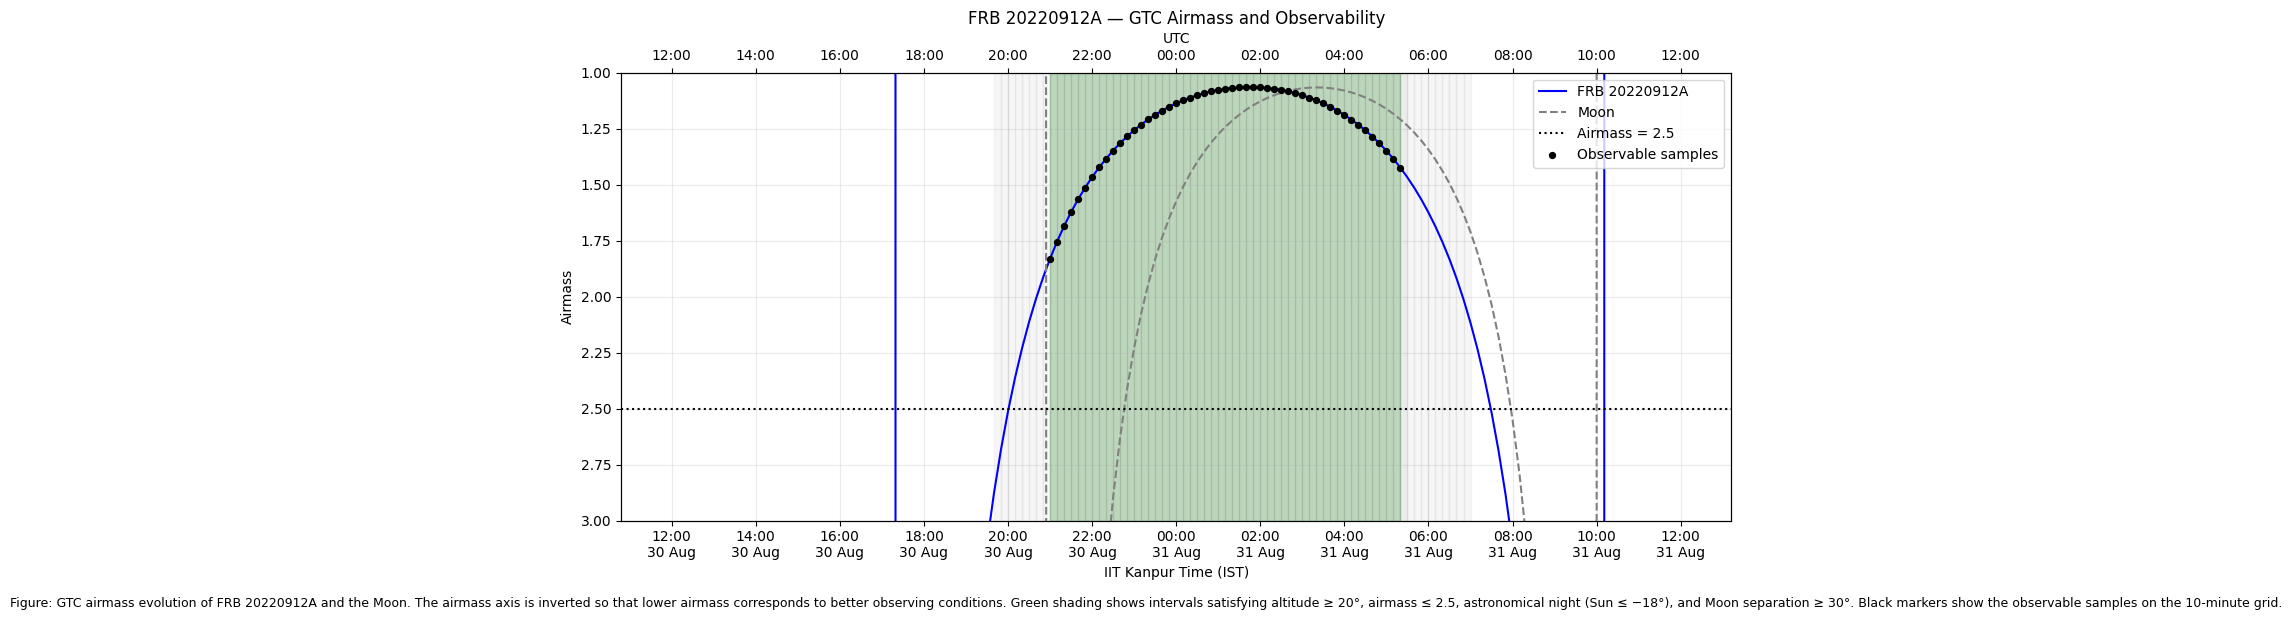

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Moon airmass
moon_altaz = moon.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

moon_airmass = np.array(moon_altaz.secz, dtype=float)

# Times in datetime for plotting
t = times.to_datetime()

fig, ax = plt.subplots(figsize=(12, 6))

# ---------------- Target and Moon ----------------

ax.plot(
    t,
    target_airmass_full,
    color="blue",
    label="FRB 20220912A"
)

ax.plot(
    t,
    moon_airmass,
    "--",
    color="gray",
    label="Moon"
)

# Airmass limit
ax.axhline(
    2.5,
    color="black",
    linestyle=":",
    label="Airmass = 2.5"
)

# ---------------- Twilight / night bands ----------------

sun_alt = sun_altaz.alt.to_value(u.deg)

# Astronomical night: Sun <= -18 deg
night = sun_alt <= -18

# Twilight: -18 < Sun <= 0
twilight = (sun_alt > -18) & (sun_alt <= 0)

# Shade contiguous regions
for i in range(len(t) - 1):

    if night[i]:
        ax.axvspan(
            t[i], t[i+1],
            color="gray",
            alpha=0.15
        )

    elif twilight[i]:
        ax.axvspan(
            t[i], t[i+1],
            color="gray",
            alpha=0.07
        )

# ---------------- Observable intervals ----------------

for start, end in windows:

    ax.axvspan(
        t[start],
        t[end],
        color="green",
        alpha=0.20
    )

# Observable 10-minute samples
observable = preferred_visibility_full

ax.scatter(
    t[observable],
    target_airmass_full[observable],
    color="black",
    s=18,
    zorder=5,
    label="Observable samples"
)

# ---------------- Axes ----------------

ax.set_ylim(3, 1)
ax.set_ylabel("Airmass")
ax.set_xlabel("IIT Kanpur Time (IST)")

ax.set_title(
    "FRB 20220912A — GTC Airmass and Observability"
)

# Date rollover
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M\n%d %b")
)

ax.grid(alpha=0.25)

# ---------------- UTC axis ----------------

ax_utc = ax.twiny()
ax_utc.set_xlim(ax.get_xlim())

ax_utc.xaxis.set_major_locator(
    mdates.HourLocator(interval=2)
)

ax_utc.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)

ax_utc.set_xlabel("UTC")

# ---------------- Legend ----------------

ax.legend(loc="upper right")

# ---------------- Caption ----------------

fig.text(
    0.5,
    -0.02,
    "Figure: GTC airmass evolution of FRB 20220912A and the Moon. "
    "The airmass axis is inverted so that lower airmass corresponds to "
    "better observing conditions. Green shading shows intervals satisfying "
    "altitude ≥ 20°, airmass ≤ 2.5, astronomical night (Sun ≤ −18°), "
    "and Moon separation ≥ 30°. Black markers show the observable samples "
    "on the 10-minute grid.",
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "assignment_outputs/frb_20220912a_gtc_airmass.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FRB 20220912A is observable with the GTC only during the intervals where the target is above 20° altitude, has airmass ≤ 2.5, the Sun is below −18°, and the Moon is at least 30° away. Within these intervals, observations are therefore feasible under the adopted scheduling constraints.
Because the visibility calculation is sampled every 10 minutes, the exact beginning and end of an observable interval may be uncertain by up to roughly one grid interval, and short visibility windows between samples could be missed.

In [26]:
import numpy as np
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import AltAz, get_sun

# 10-minute grid covering the full UTC day
times_q19 = Time(
    "2026-09-01 00:00:00"
) + np.arange(145) * 10 * u.min

# Target altitude and airmass at GTC
frb_altaz = frb_icrs.transform_to(
    AltAz(obstime=times_q19, location=gtc_location)
)

airmass = np.array(frb_altaz.secz, dtype=float)
altitude = frb_altaz.alt

# Sun altitude
sun_altaz = get_sun(times_q19).transform_to(
    AltAz(obstime=times_q19, location=gtc_location)
)

# Q19 visibility rule
visible = (
    (altitude > 0 * u.deg) &
    np.isfinite(airmass) &
    (airmass <= 2.5) &
    (sun_altaz.alt <= -18 * u.deg)
)

# Find contiguous visibility intervals
windows = []
start = None

for i in range(len(times_q19)):

    if visible[i] and start is None:
        start = i

    if start is not None and (
        i == len(times_q19) - 1 or not visible[i + 1]
    ):
        windows.append((start, i))
        start = None

# Report intervals
for start, end in windows:

    duration = (
        times_q19[end] - times_q19[start]
    ).to_value(u.hour)

    utc_start = times_q19[start]
    utc_end = times_q19[end]

    # IIT Kanpur = UTC + 5:30
    ist_start = utc_start + 5.5 * u.hour
    ist_end = utc_end + 5.5 * u.hour

    print("\nVisibility interval")
    print(
        "UTC :", utc_start.isot,
        "to", utc_end.isot
    )
    print(
        "IST :", ist_start.isot,
        "to", ist_end.isot
    )
    print(
        "Duration:", duration, "hours"
    )


Visibility interval
UTC : 2026-09-01T00:00:00.000 to 2026-09-01T05:20:00.000
IST : 2026-09-01T05:30:00.000 to 2026-09-01T10:50:00.000
Duration: 5.333333333333333 hours

Visibility interval
UTC : 2026-09-01T21:00:00.000 to 2026-09-02T00:00:00.000
IST : 2026-09-02T02:30:00.000 to 2026-09-02T05:30:00.000
Duration: 3.0 hours


For 2026-09-01, FRB 20220912A is visible from the GTC during two intervals. The first interval is 00:00–05:20 UTC (05:30–10:50 IST), lasting 5.33 h. The second interval is 21:00 UTC on September 1 to 00:00 UTC on September 2 (02:30–05:30 IST on September 2), lasting 3.00 h. Thus, the total visibility duration is approximately 8.33 h. The visibility criterion requires the source to be above the horizon, have airmass ≤ 2.5, and occur during astronomical night; no Moon constraint is applied.
the second interval crossing midnight is correctly reported as September 2 in IST. That's because IST is UTC+5:30.

In [28]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, AltAz, get_sun
import os
import imageio.v2 as imageio
# Moderate HEALPix resolution
nside = 32
npix = hp.nside2npix(nside)

# HEALPix pixel centres
theta, phi = hp.pix2ang(nside, np.arange(npix))

ra = phi * u.rad
dec = (np.pi/2 - theta) * u.rad

sky = SkyCoord(ra=ra, dec=dec, frame="icrs")

# Weekly dates: 2026-08-30 to 2027-08-29
dates = Time("2026-08-30") + np.arange(53) * 7 * u.day

os.makedirs("assignment_outputs/gtc_frames", exist_ok=True)

frames = []

for k, date in enumerate(dates):

    # GTC AltAz transformation
    altaz = sky.transform_to(
        AltAz(obstime=date, location=gtc_location)
    )

    altitude = altaz.alt
    airmass = np.array(altaz.secz, dtype=float)

    # Sun altitude
    sun_altaz = get_sun(date).transform_to(
        AltAz(obstime=date, location=gtc_location)
    )

    # Visibility condition
    visible = (
        (altitude > 0 * u.deg) &
        np.isfinite(airmass) &
        (airmass <= 2.5) &
        (sun_altaz.alt <= -18 * u.deg)
    )

    # HEALPix map: 1 = visible, 0 = not visible
    visibility_map = visible.astype(float)

    # Plot
    fig = plt.figure(figsize=(9, 5))

    hp.mollview(
        visibility_map,
        fig=fig.number,
        title=f"GTC Observable Sky — {date.isot[:10]}",
        min=0,
        max=1,
        cbar=False,
        cmap="Greens",
        badcolor="white"
    )

    hp.graticule()

    filename = (
        f"assignment_outputs/gtc_frames/"
        f"gtc_{date.isot[:10]}.png"
    )

    plt.savefig(filename, dpi=120, bbox_inches="tight")
    plt.close()

    frames.append(imageio.imread(filename))

# Combine into GIF
imageio.mimsave(
    "assignment_outputs/gtc_visibility_year.gif",
    frames,
    duration=0.25,
    loop=0
)

print("Saved:")
print(
"assignment_outputs/gtc_visibility_year.gif")

Saved:
assignment_outputs/gtc_visibility_year.gif
